In [ ]:
!pip install qiskit_aer qiskit_machine_learning qiskit imblearn pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 8.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a6826542ce81aaedc96cfd2749ad608e4da18f544e61ab6462f8b7e4084fac18
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a17

Device: cuda | n_qubits=2 REPS=1
Original distribution: [19575   425]
Epoch 1 | Loss=0.0091 | Val F1=0.6145
Epoch 2 | Loss=0.0050 | Val F1=0.6220
Epoch 3 | Loss=0.0044 | Val F1=0.6228
Epoch 4 | Loss=0.0043 | Val F1=0.6012
Epoch 5 | Loss=0.0041 | Val F1=0.6049

               precision    recall  f1-score   support

           0       1.00      0.97      0.99      5873
           1       0.43      1.00      0.60       127

    accuracy                           0.97      6000
   macro avg       0.71      0.99      0.79      6000
weighted avg       0.99      0.97      0.98      6000



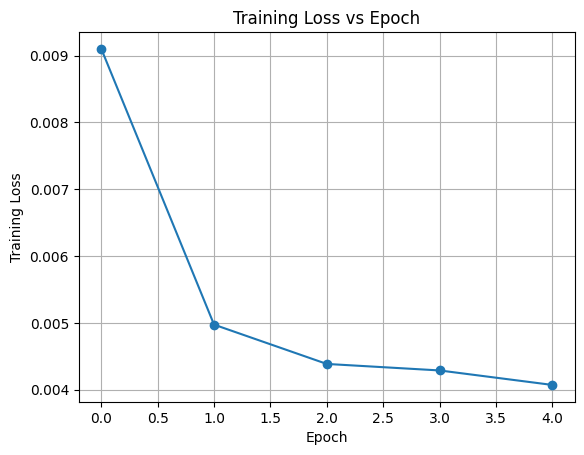

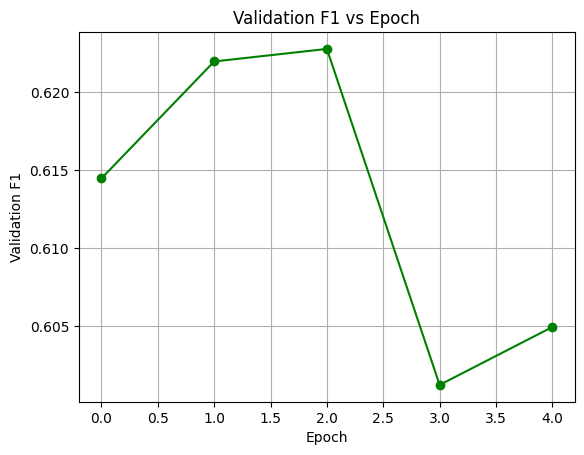

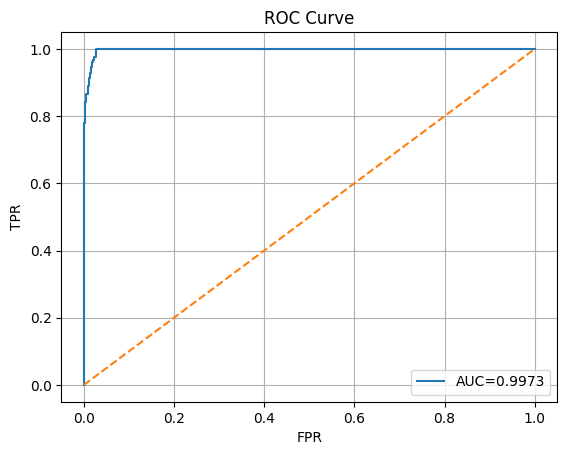

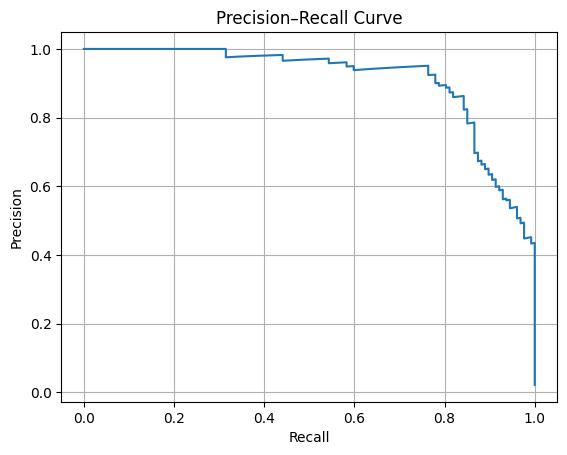

Model saved.


In [ ]:
import os
import time
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

try:
    from qiskit.primitives import Sampler
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.neural_networks import SamplerQNN
    from qiskit_machine_learning.connectors import TorchConnector
except Exception as e:
    raise ImportError("Qiskit imports failed.") from e

# ---------------- CONFIG ----------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_QUBITS = 2
REPS = 1
BATCH_SIZE = 75
EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-5
LOG_EVERY_BATCHES = 75
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

warnings.filterwarnings("ignore")
print(f"Device: {DEVICE} | n_qubits={N_QUBITS} REPS={REPS}")

# ---------------- FOCAL LOSS ----------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, inputs, targets):
        logpt = -self.ce(inputs, targets)
        pt = torch.exp(logpt)
        loss = -self.alpha * ((1 - pt) ** self.gamma) * logpt
        return loss.mean()

# ---------------- LOAD DATA ----------------
embeddings = np.load("node_embeddings.npy")
labels = np.load("node_labels.npy").astype(int)

print("Original distribution:", np.bincount(labels))

train_idx, test_idx = train_test_split(
    np.arange(len(labels)), test_size=0.30, stratify=labels, random_state=SEED
)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.176, stratify=labels[train_idx], random_state=SEED
)

X_train, y_train = embeddings[train_idx], labels[train_idx]
X_val, y_val = embeddings[val_idx], labels[val_idx]
X_test, y_test = embeddings[test_idx], labels[test_idx]

sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# ---------------- PCA + SCALE ----------------
pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_res)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)

Xtr = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
Ytr = torch.tensor(y_train_res, dtype=torch.long, device=DEVICE)
Xval = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
Yval = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
Yte = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

# ---------------- QNN ----------------
feature_map = ZZFeatureMap(N_QUBITS, reps=REPS)
ansatz = RealAmplitudes(N_QUBITS, reps=REPS)
qc = feature_map.compose(ansatz)

qnn = SamplerQNN(
    sampler=Sampler(),
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
)

torch_qnn = TorchConnector(qnn).to(DEVICE)

with torch.no_grad():
    qnn_out_dim = torch_qnn(Xtr[:2]).shape[-1]

class QuantumClassifier(nn.Module):
    def __init__(self, qnn, out_dim):
        super().__init__()
        self.qnn = qnn
        self.fc = nn.Sequential(
            nn.Linear(out_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.fc(self.qnn(x))

model = QuantumClassifier(torch_qnn, qnn_out_dim).to(DEVICE)

# ---------------- TRAINING ----------------
loss_fn = FocalLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_loss_hist, val_f1_hist = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []

    perm = torch.randperm(len(Xtr))
    for i in range(0, len(Xtr), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        optimizer.zero_grad()
        loss = loss_fn(model(Xtr[idx]), Ytr[idx])
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(Xval)
        val_preds = val_logits.argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val, val_preds)

    train_loss_hist.append(np.mean(losses))
    val_f1_hist.append(val_f1)

    print(f"Epoch {epoch} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

# ---------------- TEST ----------------
model.eval()
with torch.no_grad():
    test_logits = model(Xte)
    test_preds = test_logits.argmax(dim=1).cpu().numpy()
    test_prob = torch.softmax(test_logits, dim=1).cpu().numpy()[:,1]

test_auc = roc_auc_score(y_test, test_prob)
print("\n", classification_report(y_test, test_preds))

# ---------------- GRAPHS ----------------

# Loss curve
plt.figure()
plt.plot(train_loss_hist, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid()
plt.show()

# F1 curve
plt.figure()
plt.plot(val_f1_hist, marker='o', color='green')
plt.xlabel("Epoch")
plt.ylabel("Validation F1")
plt.title("Validation F1 vs Epoch")
plt.grid()
plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_test, test_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={test_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, test_prob)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid()
plt.show()

torch.save(model.state_dict(), "qmodel_final.pt")
print("Model saved.")


In [ ]:
import os
import time
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Qiskit imports (v2 primitives style)
try:
    from qiskit.primitives import Sampler
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.neural_networks import SamplerQNN
    from qiskit_machine_learning.connectors import TorchConnector
except Exception as e:
    raise ImportError("Qiskit / qiskit-machine-learning imports failed. "
                      "Check installed qiskit, qiskit-machine-learning and qiskit-primitives.") from e

# ---------------------------
# Config (Option B: Balanced)
# ---------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_QUBITS = 2
REPS = 1               # balanced expressive depth
BATCH_SIZE = 75
EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-5
LOG_EVERY_BATCHES = 75   # print every 50 batches
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

warnings.filterwarnings("ignore")
print(f"Device: {DEVICE} | n_qubits={N_QUBITS} REPS={REPS}")

# ---------------------------
# Focal Loss implementation
# ---------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, inputs, targets):
        # inputs: [B, C], targets: [B]
        logpt = -self.ce(inputs, targets)         # negative cross-entropy per sample
        pt = torch.exp(logpt)                     # p_t
        focal_term = (1 - pt) ** self.gamma
        loss = -self.alpha * focal_term * logpt
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

# ---------------------------
# Load embeddings (from GNN)
# ---------------------------
EMB_PATH = "node_embeddings.npy"
LABEL_PATH = "node_labels.npy"
if not (os.path.exists(EMB_PATH) and os.path.exists(LABEL_PATH)):
    raise FileNotFoundError("Make sure node_embeddings.npy and node_labels.npy exist in cwd.")

embeddings = np.load(EMB_PATH)   # shape [N, emb_dim]
labels = np.load(LABEL_PATH).astype(int)

print("Loaded embeddings:", embeddings.shape, "labels:", labels.shape)
print("Original class distribution:", np.bincount(labels))

# ---------------------------
# Train/Val/Test split (use consistent split)
# ---------------------------
# If original split indices exist in your pipeline, use them. Here we do a deterministic split.
train_idx, test_idx = train_test_split(np.arange(len(labels)),
                                       test_size=0.30,
                                       stratify=labels,
                                       random_state=SEED)
# split train into train/val
train_idx, val_idx = train_test_split(train_idx,
                                     test_size=0.1764705882,  # so final val ~15% overall: 0.15/(1-0.3)=0.214... pick approx
                                     stratify=labels[train_idx],
                                     random_state=SEED)

X_train = embeddings[train_idx]
y_train = labels[train_idx]
X_val = embeddings[val_idx]
y_val = labels[val_idx]
X_test = embeddings[test_idx]
y_test = labels[test_idx]

print("Split sizes -> train:", len(X_train), "val:", len(X_val), "test:", len(X_test))
print("Train class dist before SMOTE:", np.bincount(y_train))

# ---------------------------
# Apply SMOTE on train only
# ---------------------------
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Train class dist after SMOTE:", np.bincount(y_train_res))

# ---------------------------
# PCA -> reduce to N_QUBITS dims
# ---------------------------
pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_res)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# ---------------------------
# Scale to [0, pi] for angle encoding
# ---------------------------
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)

# ---------------------------
# Torch tensors (on DEVICE)
# ---------------------------
Xtr = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
Ytr = torch.tensor(y_train_res, dtype=torch.long, device=DEVICE)
Xval = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
Yval = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
Yte = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

# ---------------------------
# Build QNN (ZZFeatureMap + RealAmplitudes) using Sampler primitive
# ---------------------------
feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=REPS)
ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=REPS)
qc = feature_map.compose(ansatz)

# Sampler primitive (uses local qiskit backend)
sampler = Sampler()   # requires qiskit-primitives support in installed Qiskit

qnn = SamplerQNN(
    sampler=sampler,
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
)

torch_qnn = TorchConnector(qnn).to(DEVICE)

# quick forward to determine qnn output dim
with torch.no_grad():
    sample_out = torch_qnn(Xtr[:2])
print("QNN sample output shape:", sample_out.shape)   # expect [B, out_dim]

qnn_out_dim = int(sample_out.shape[-1])

# ---------------------------
# PyTorch classifier wrapping the QNN
# ---------------------------
class QuantumClassifier(nn.Module):
    def __init__(self, qnn_module: nn.Module, qnn_out_dim: int, mid_dim: int = 32):
        super().__init__()
        self.qnn = qnn_module
        # small MLP on top of QNN outputs
        self.mlp = nn.Sequential(
            nn.Linear(qnn_out_dim, mid_dim),
            nn.ReLU(),
            nn.BatchNorm1d(mid_dim),
            nn.Linear(mid_dim, 2)
        )

    def forward(self, x):
        qout = self.qnn(x)            # shape [B, qnn_out_dim]
        return self.mlp(qout)

qmodel = QuantumClassifier(torch_qnn, qnn_out_dim).to(DEVICE)

# ---------------------------
# Training setup
# ---------------------------
loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = AdamW(qmodel.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

n_train = len(Xtr)
n_batches = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Train samples: {n_train}, batches per epoch: {n_batches}")

# ---------------------------
# Training loop with logging
# ---------------------------
best_val_f1 = 0.0
best_state = None

start_time_all = time.time()
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    perm = torch.randperm(n_train, device=DEVICE)
    qmodel.train()
    batch_losses = []
    for b_idx in range(0, n_train, BATCH_SIZE):
        batch_idx = perm[b_idx:b_idx + BATCH_SIZE]
        xb = Xtr[batch_idx]
        yb = Ytr[batch_idx]

        optimizer.zero_grad()
        logits = qmodel(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        # periodic batch log
        if ((b_idx // BATCH_SIZE) + 1) % LOG_EVERY_BATCHES == 0:
            print(f"Epoch {epoch} | Batch {(b_idx//BATCH_SIZE)+1}/{n_batches} | loss={loss.item():.4f}")

    scheduler.step()

    # validation
    qmodel.eval()
    with torch.no_grad():
        val_logits = qmodel(Xval)
        val_preds = val_logits.argmax(dim=1).cpu().numpy()
        val_acc = accuracy_score(Yval.cpu().numpy(), val_preds)
        val_f1 = f1_score(Yval.cpu().numpy(), val_preds, zero_division=0)
        try:
            val_prob = torch.softmax(val_logits, dim=1).cpu().numpy()[:, 1]
            val_auc = roc_auc_score(Yval.cpu().numpy(), val_prob)
        except Exception:
            val_auc = None

    mean_loss = float(np.mean(batch_losses)) if batch_losses else 0.0
    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch} completed | mean_loss={mean_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | val_auc={val_auc} | time={epoch_time:.1f}s")

    # save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {
            "model_state": qmodel.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_f1": val_f1
        }
        torch.save(best_state, "qmodel_best_1.pt")
        print(f"Saved best model at epoch {epoch} with val_f1={val_f1:.4f}")

total_time = time.time() - start_time_all
print(f"Training finished in {total_time/60:.2f} minutes. Best val_f1={best_val_f1:.4f}")

# ---------------------------
# Final test evaluation (load best if available)
# ---------------------------
if best_state is not None:
    qmodel.load_state_dict(best_state["model_state"])

qmodel.eval()
with torch.no_grad():
    test_logits = qmodel(Xte)
    test_preds = test_logits.argmax(dim=1).cpu().numpy()
    test_acc = accuracy_score(Yte.cpu().numpy(), test_preds)
    test_f1 = f1_score(Yte.cpu().numpy(), test_preds, zero_division=0)
    try:
        test_prob = torch.softmax(test_logits, dim=1).cpu().numpy()[:, 1]
        test_auc = roc_auc_score(Yte.cpu().numpy(), test_prob)
    except Exception:
        test_auc = None

print("\n===== TEST RESULTS =====")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print(f"Test AUC:      {test_auc}")
print("\nClassification report:")
print(classification_report(Yte.cpu().numpy(), test_preds, zero_division=0))

# save final model
torch.save(qmodel.state_dict(), "qmodel_final_1.pt")
print("Saved final model to qmodel_final_1.pt")


Device: cuda | n_qubits=2 REPS=1
Loaded embeddings: (20000, 16) labels: (20000,)
Original class distribution: [19575   425]
Split sizes -> train: 11529 val: 2471 test: 6000
Train class dist before SMOTE: [11284   245]
Train class dist after SMOTE: [11284 11284]
QNN sample output shape: torch.Size([2, 4])
Train samples: 22568, batches per epoch: 301
Epoch 1 | Batch 75/301 | loss=0.0098
Epoch 1 | Batch 150/301 | loss=0.0048
Epoch 1 | Batch 225/301 | loss=0.0077
Epoch 1 | Batch 300/301 | loss=0.0039
Epoch 1 completed | mean_loss=0.0089 | val_acc=0.9741 | val_f1=0.6190 | val_auc=0.9942959252149758 | time=161.5s
Saved best model at epoch 1 with val_f1=0.6190
Epoch 2 | Batch 75/301 | loss=0.0015
Epoch 2 | Batch 150/301 | loss=0.0022
Epoch 2 | Batch 225/301 | loss=0.0021
Epoch 2 | Batch 300/301 | loss=0.0020
Epoch 2 completed | mean_loss=0.0050 | val_acc=0.9741 | val_f1=0.6235 | val_auc=0.9954585888852475 | time=158.8s
Saved best model at epoch 2 with val_f1=0.6235
Epoch 3 | Batch 75/301 | lo

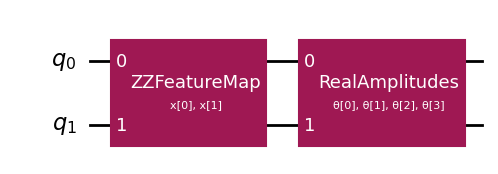

In [ ]:
qc.draw('mpl')

In [ ]:
import os
import time
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Qiskit imports
try:
    from qiskit.primitives import Sampler
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.neural_networks import SamplerQNN
    from qiskit_machine_learning.connectors import TorchConnector
except Exception as e:
    raise ImportError("Qiskit / qiskit-machine-learning imports failed.") from e

# ---------------------------
# Config
# ---------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_QUBITS = 2
REPS = 1
BATCH_SIZE = 75
EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-5
LOG_EVERY_BATCHES = 75
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warnings.filterwarnings("ignore")
print(f"Device: {DEVICE} | n_qubits={N_QUBITS} REPS={REPS}")

# ---------------------------
# Load embeddings
# ---------------------------
EMB_PATH = "node_embeddings.npy"
LABEL_PATH = "node_labels.npy"
if not (os.path.exists(EMB_PATH) and os.path.exists(LABEL_PATH)):
    raise FileNotFoundError("Make sure node_embeddings.npy and node_labels.npy exist.")

embeddings = np.load(EMB_PATH)
labels = np.load(LABEL_PATH).astype(int)
print("Loaded embeddings:", embeddings.shape, "labels:", labels.shape)
print("Original class distribution:", np.bincount(labels))

# ---------------------------
# Train/Val/Test split
# ---------------------------
train_idx, test_idx = train_test_split(np.arange(len(labels)),
                                       test_size=0.30,
                                       stratify=labels,
                                       random_state=SEED)
train_idx, val_idx = train_test_split(train_idx,
                                     test_size=0.1764705882,
                                     stratify=labels[train_idx],
                                     random_state=SEED)

X_train = embeddings[train_idx]
y_train = labels[train_idx]
X_val = embeddings[val_idx]
y_val = labels[val_idx]
X_test = embeddings[test_idx]
y_test = labels[test_idx]

print("Split sizes -> train:", len(X_train), "val:", len(X_val), "test:", len(X_test))
print("Train class dist before SMOTE:", np.bincount(y_train))

# ---------------------------
# Apply SMOTE on train
# ---------------------------
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Train class dist after SMOTE:", np.bincount(y_train_res))

# ---------------------------
# PCA + Scale
# ---------------------------
pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_res)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)

# ---------------------------
# Torch tensors
# ---------------------------
Xtr = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
Ytr = torch.tensor(y_train_res.reshape(-1,1), dtype=torch.float32, device=DEVICE)  # BCE expects float [B,1]
Xval = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
Yval = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32, device=DEVICE)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
Yte = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32, device=DEVICE)

# ---------------------------
# Build QNN
# ---------------------------
feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=REPS)
ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=REPS)
qc = feature_map.compose(ansatz)
sampler = Sampler()

qnn = SamplerQNN(
    sampler=sampler,
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
)

torch_qnn = TorchConnector(qnn).to(DEVICE)

with torch.no_grad():
    sample_out = torch_qnn(Xtr[:2])
qnn_out_dim = int(sample_out.shape[-1])
print("QNN sample output shape:", sample_out.shape)

# ---------------------------
# Quantum classifier (single logit)
# ---------------------------
class QuantumClassifier(nn.Module):
    def __init__(self, qnn_module: nn.Module, qnn_out_dim: int, mid_dim: int = 32):
        super().__init__()
        self.qnn = qnn_module
        self.mlp = nn.Sequential(
            nn.Linear(qnn_out_dim, mid_dim),
            nn.ReLU(),
            nn.BatchNorm1d(mid_dim),
            nn.Linear(mid_dim, 1)  # single logit for BCE
        )

    def forward(self, x):
        qout = self.qnn(x)
        return self.mlp(qout)

qmodel = QuantumClassifier(torch_qnn, qnn_out_dim).to(DEVICE)

# ---------------------------
# Training setup
# ---------------------------
loss_fn = nn.BCEWithLogitsLoss()
optimizer = AdamW(qmodel.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

n_train = len(Xtr)
n_batches = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Train samples: {n_train}, batches per epoch: {n_batches}")

# ---------------------------
# Training loop
# ---------------------------
best_val_f1 = 0.0
best_state = None
start_time_all = time.time()

for epoch in range(1, EPOCHS+1):
    epoch_start = time.time()
    perm = torch.randperm(n_train, device=DEVICE)
    qmodel.train()
    batch_losses = []

    for b_idx in range(0, n_train, BATCH_SIZE):
        batch_idx = perm[b_idx:b_idx+BATCH_SIZE]
        xb = Xtr[batch_idx]
        yb = Ytr[batch_idx]

        optimizer.zero_grad()
        logits = qmodel(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

        if ((b_idx // BATCH_SIZE) + 1) % LOG_EVERY_BATCHES == 0:
            print(f"Epoch {epoch} | Batch {(b_idx//BATCH_SIZE)+1}/{n_batches} | loss={loss.item():.4f}")

    scheduler.step()

    # validation
    qmodel.eval()
    with torch.no_grad():
        val_logits = qmodel(Xval)
        val_prob = torch.sigmoid(val_logits).cpu().numpy()
        val_preds = (val_prob > 0.5).astype(int)
        val_acc = accuracy_score(Yval.cpu().numpy(), val_preds)
        val_f1 = f1_score(Yval.cpu().numpy(), val_preds, zero_division=0)
        val_auc = roc_auc_score(Yval.cpu().numpy(), val_prob)

    mean_loss = float(np.mean(batch_losses))
    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch} completed | mean_loss={mean_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | val_auc={val_auc:.4f} | time={epoch_time:.1f}s")

    # save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {
            "model_state": qmodel.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_f1": val_f1
        }
        torch.save(best_state, "qmodel_best_bce.pt")
        print(f"Saved best model at epoch {epoch} with val_f1={val_f1:.4f}")

total_time = time.time() - start_time_all
print(f"Training finished in {total_time/60:.2f} minutes. Best val_f1={best_val_f1:.4f}")

# ---------------------------
# Final test evaluation
# ---------------------------
if best_state is not None:
    qmodel.load_state_dict(best_state["model_state"])

qmodel.eval()
with torch.no_grad():
    test_logits = qmodel(Xte)
    test_prob = torch.sigmoid(test_logits).cpu().numpy()
    test_preds = (test_prob > 0.5).astype(int)
    test_acc = accuracy_score(Yte.cpu().numpy(), test_preds)
    test_f1 = f1_score(Yte.cpu().numpy(), test_preds, zero_division=0)
    test_auc = roc_auc_score(Yte.cpu().numpy(), test_prob)

print("\n===== TEST RESULTS =====")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print(f"Test AUC:      {test_auc:.4f}")
print("\nClassification report:")
print(classification_report(Yte.cpu().numpy(), test_preds, zero_division=0))

torch.save(qmodel.state_dict(), "qmodel_final_bce.pt")
print("Saved final model to qmodel_final_bce.pt")


Device: cuda | n_qubits=2 REPS=1
Loaded embeddings: (20000, 16) labels: (20000,)
Original class distribution: [19575   425]
Split sizes -> train: 11529 val: 2471 test: 6000
Train class dist before SMOTE: [11284   245]
Train class dist after SMOTE: [11284 11284]
QNN sample output shape: torch.Size([2, 4])
Train samples: 22568, batches per epoch: 301
Epoch 1 | Batch 75/301 | loss=0.3257
Epoch 1 | Batch 150/301 | loss=0.1525
Epoch 1 | Batch 225/301 | loss=0.1216
Epoch 1 | Batch 300/301 | loss=0.0827
Epoch 1 completed | mean_loss=0.2594 | val_acc=0.9729 | val_f1=0.6082 | val_auc=0.9886 | time=184.3s
Saved best model at epoch 1 with val_f1=0.6082
Epoch 2 | Batch 75/301 | loss=0.0407
Epoch 2 | Batch 150/301 | loss=0.0571
Epoch 2 | Batch 225/301 | loss=0.0395
Epoch 2 | Batch 300/301 | loss=0.0589
Epoch 2 completed | mean_loss=0.0951 | val_acc=0.9737 | val_f1=0.6154 | val_auc=0.9940 | time=183.0s
Saved best model at epoch 2 with val_f1=0.6154
Epoch 3 | Batch 75/301 | loss=0.0684
Epoch 3 | Batc

In [ ]:
import os
import time
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Qiskit imports
try:
    from qiskit.primitives import Sampler
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.neural_networks import SamplerQNN
    from qiskit_machine_learning.connectors import TorchConnector
except Exception as e:
    raise ImportError("Qiskit / qiskit-machine-learning imports failed.") from e

# ---------------------------
# Config
# ---------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_QUBITS = 2
REPS = 1
BATCH_SIZE = 75
EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-5
LOG_EVERY_BATCHES = 75
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warnings.filterwarnings("ignore")
print(f"Device: {DEVICE} | n_qubits={N_QUBITS} REPS={REPS}")

# ---------------------------
# Load embeddings
# ---------------------------
EMB_PATH = "node_embeddings.npy"
LABEL_PATH = "node_labels.npy"
if not (os.path.exists(EMB_PATH) and os.path.exists(LABEL_PATH)):
    raise FileNotFoundError("Make sure node_embeddings.npy and node_labels.npy exist.")

embeddings = np.load(EMB_PATH)
labels = np.load(LABEL_PATH).astype(int)
print("Loaded embeddings:", embeddings.shape, "labels:", labels.shape)
print("Original class distribution:", np.bincount(labels))

# ---------------------------
# Train/Val/Test split
# ---------------------------
train_idx, test_idx = train_test_split(np.arange(len(labels)),
                                       test_size=0.30,
                                       stratify=labels,
                                       random_state=SEED)
train_idx, val_idx = train_test_split(train_idx,
                                     test_size=0.1764705882,
                                     stratify=labels[train_idx],
                                     random_state=SEED)

X_train = embeddings[train_idx]
y_train = labels[train_idx]
X_val = embeddings[val_idx]
y_val = labels[val_idx]
X_test = embeddings[test_idx]
y_test = labels[test_idx]

print("Split sizes -> train:", len(X_train), "val:", len(X_val), "test:", len(X_test))
print("Train class dist before SMOTE:", np.bincount(y_train))

# ---------------------------
# Apply SMOTE on train
# ---------------------------
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Train class dist after SMOTE:", np.bincount(y_train_res))

# ---------------------------
# PCA + Scale
# ---------------------------
pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_res)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)

# ---------------------------
# Torch tensors
# ---------------------------
Xtr = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
Ytr = torch.tensor(y_train_res.reshape(-1,1), dtype=torch.float32, device=DEVICE)  # BCE expects float [B,1]
Xval = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
Yval = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32, device=DEVICE)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
Yte = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32, device=DEVICE)

# ---------------------------
# Build QNN
# ---------------------------
feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=REPS)
ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=REPS)
qc = feature_map.compose(ansatz)
sampler = Sampler()

qnn = SamplerQNN(
    sampler=sampler,
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
)

torch_qnn = TorchConnector(qnn).to(DEVICE)

with torch.no_grad():
    sample_out = torch_qnn(Xtr[:2])
qnn_out_dim = int(sample_out.shape[-1])
print("QNN sample output shape:", sample_out.shape)

# ---------------------------
# Quantum classifier (single logit)
# ---------------------------
class QuantumClassifier(nn.Module):
    def __init__(self, qnn_module: nn.Module, qnn_out_dim: int, mid_dim: int = 32):
        super().__init__()
        self.qnn = qnn_module
        self.mlp = nn.Sequential(
            nn.Linear(qnn_out_dim, mid_dim),
            nn.ReLU(),
            nn.BatchNorm1d(mid_dim),
            nn.Linear(mid_dim, 1)  # single logit for BCE
        )

    def forward(self, x):
        qout = self.qnn(x)
        return self.mlp(qout)

qmodel = QuantumClassifier(torch_qnn, qnn_out_dim).to(DEVICE)

# ---------------------------
# Training setup
# ---------------------------
loss_fn = nn.BCEWithLogitsLoss()
optimizer = AdamW(qmodel.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

n_train = len(Xtr)
n_batches = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Train samples: {n_train}, batches per epoch: {n_batches}")

# ---------------------------
# Training loop
# ---------------------------
best_val_f1 = 0.0
best_state = None
start_time_all = time.time()

for epoch in range(1, EPOCHS+1):
    epoch_start = time.time()
    perm = torch.randperm(n_train, device=DEVICE)
    qmodel.train()
    batch_losses = []

    for b_idx in range(0, n_train, BATCH_SIZE):
        batch_idx = perm[b_idx:b_idx+BATCH_SIZE]
        xb = Xtr[batch_idx]
        yb = Ytr[batch_idx]

        optimizer.zero_grad()
        logits = qmodel(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

        if ((b_idx // BATCH_SIZE) + 1) % LOG_EVERY_BATCHES == 0:
            print(f"Epoch {epoch} | Batch {(b_idx//BATCH_SIZE)+1}/{n_batches} | loss={loss.item():.4f}")

    scheduler.step()

    # validation
    qmodel.eval()
    with torch.no_grad():
        val_logits = qmodel(Xval)
        val_prob = torch.sigmoid(val_logits).cpu().numpy()
        val_preds = (val_prob > 0.5).astype(int)
        val_acc = accuracy_score(Yval.cpu().numpy(), val_preds)
        val_f1 = f1_score(Yval.cpu().numpy(), val_preds, zero_division=0)
        val_auc = roc_auc_score(Yval.cpu().numpy(), val_prob)

    mean_loss = float(np.mean(batch_losses))
    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch} completed | mean_loss={mean_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | val_auc={val_auc:.4f} | time={epoch_time:.1f}s")

    # save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {
            "model_state": qmodel.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_f1": val_f1
        }
        torch.save(best_state, "qmodel_best_bce_1.pt")
        print(f"Saved best model at epoch {epoch} with val_f1={val_f1:.4f}")

total_time = time.time() - start_time_all
print(f"Training finished in {total_time/60:.2f} minutes. Best val_f1={best_val_f1:.4f}")

# ---------------------------
# Final test evaluation
# ---------------------------
if best_state is not None:
    qmodel.load_state_dict(best_state["model_state"])

qmodel.eval()
with torch.no_grad():
    test_logits = qmodel(Xte)
    test_prob = torch.sigmoid(test_logits).cpu().numpy()
    test_preds = (test_prob > 0.5).astype(int)
    test_acc = accuracy_score(Yte.cpu().numpy(), test_preds)
    test_f1 = f1_score(Yte.cpu().numpy(), test_preds, zero_division=0)
    test_auc = roc_auc_score(Yte.cpu().numpy(), test_prob)

print("\n===== TEST RESULTS =====")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print(f"Test AUC:      {test_auc:.4f}")
print("\nClassification report:")
print(classification_report(Yte.cpu().numpy(), test_preds, zero_division=0))

torch.save(qmodel.state_dict(), "qmodel_final_bce_1.pt")
print("Saved final model to qmodel_final_bce_1.pt")


Device: cuda | n_qubits=2 REPS=1
Loaded embeddings: (20000, 16) labels: (20000,)
Original class distribution: [19575   425]
Split sizes -> train: 11529 val: 2471 test: 6000
Train class dist before SMOTE: [11284   245]
Train class dist after SMOTE: [11284 11284]
QNN sample output shape: torch.Size([2, 4])
Train samples: 22568, batches per epoch: 301
Epoch 1 | Batch 75/301 | loss=0.3257
Epoch 1 | Batch 150/301 | loss=0.1525
Epoch 1 | Batch 225/301 | loss=0.1216
Epoch 1 | Batch 300/301 | loss=0.0827
Epoch 1 completed | mean_loss=0.2594 | val_acc=0.9729 | val_f1=0.6082 | val_auc=0.9886 | time=185.9s
Saved best model at epoch 1 with val_f1=0.6082
Epoch 2 | Batch 75/301 | loss=0.0407
Epoch 2 | Batch 150/301 | loss=0.0571
Epoch 2 | Batch 225/301 | loss=0.0395
Epoch 2 | Batch 300/301 | loss=0.0589
Epoch 2 completed | mean_loss=0.0951 | val_acc=0.9737 | val_f1=0.6154 | val_auc=0.9940 | time=182.1s
Saved best model at epoch 2 with val_f1=0.6154
Epoch 3 | Batch 75/301 | loss=0.0684
Epoch 3 | Batc

In [ ]:
import os
import time
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Qiskit imports (v2 primitives style)
try:
    from qiskit.primitives import Sampler
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.neural_networks import SamplerQNN
    from qiskit_machine_learning.connectors import TorchConnector
except Exception as e:
    raise ImportError("Qiskit / qiskit-machine-learning imports failed. "
                      "Check installed qiskit, qiskit-machine-learning and qiskit-primitives.") from e

# ---------------------------
# Config (Option B: Balanced)
# ---------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_QUBITS = 3
REPS = 1               # balanced expressive depth
BATCH_SIZE = 75
EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-5
LOG_EVERY_BATCHES = 75   # print every 50 batches
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

warnings.filterwarnings("ignore")
print(f"Device: {DEVICE} | n_qubits={N_QUBITS} REPS={REPS}")

# ---------------------------
# Focal Loss implementation
# ---------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, inputs, targets):
        # inputs: [B, C], targets: [B]
        logpt = -self.ce(inputs, targets)         # negative cross-entropy per sample
        pt = torch.exp(logpt)                     # p_t
        focal_term = (1 - pt) ** self.gamma
        loss = -self.alpha * focal_term * logpt
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

# ---------------------------
# Load embeddings (from GNN)
# ---------------------------
EMB_PATH = "node_embeddings.npy"
LABEL_PATH = "node_labels.npy"
if not (os.path.exists(EMB_PATH) and os.path.exists(LABEL_PATH)):
    raise FileNotFoundError("Make sure node_embeddings.npy and node_labels.npy exist in cwd.")

embeddings = np.load(EMB_PATH)   # shape [N, emb_dim]
labels = np.load(LABEL_PATH).astype(int)

print("Loaded embeddings:", embeddings.shape, "labels:", labels.shape)
print("Original class distribution:", np.bincount(labels))

# ---------------------------
# Train/Val/Test split (use consistent split)
# ---------------------------
# If original split indices exist in your pipeline, use them. Here we do a deterministic split.
train_idx, test_idx = train_test_split(np.arange(len(labels)),
                                       test_size=0.30,
                                       stratify=labels,
                                       random_state=SEED)
# split train into train/val
train_idx, val_idx = train_test_split(train_idx,
                                     test_size=0.1764705882,  # so final val ~15% overall: 0.15/(1-0.3)=0.214... pick approx
                                     stratify=labels[train_idx],
                                     random_state=SEED)

X_train = embeddings[train_idx]
y_train = labels[train_idx]
X_val = embeddings[val_idx]
y_val = labels[val_idx]
X_test = embeddings[test_idx]
y_test = labels[test_idx]

print("Split sizes -> train:", len(X_train), "val:", len(X_val), "test:", len(X_test))
print("Train class dist before SMOTE:", np.bincount(y_train))

# ---------------------------
# Apply SMOTE on train only
# ---------------------------
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Train class dist after SMOTE:", np.bincount(y_train_res))

# ---------------------------
# PCA -> reduce to N_QUBITS dims
# ---------------------------
pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_res)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# ---------------------------
# Scale to [0, pi] for angle encoding
# ---------------------------
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)

# ---------------------------
# Torch tensors (on DEVICE)
# ---------------------------
Xtr = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
Ytr = torch.tensor(y_train_res, dtype=torch.long, device=DEVICE)
Xval = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
Yval = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
Yte = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

# ---------------------------
# Build QNN (ZZFeatureMap + RealAmplitudes) using Sampler primitive
# ---------------------------
feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=REPS)
ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=REPS)
qc = feature_map.compose(ansatz)

# Sampler primitive (uses local qiskit backend)
sampler = Sampler()   # requires qiskit-primitives support in installed Qiskit

qnn = SamplerQNN(
    sampler=sampler,
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
)

torch_qnn = TorchConnector(qnn).to(DEVICE)

# quick forward to determine qnn output dim
with torch.no_grad():
    sample_out = torch_qnn(Xtr[:2])
print("QNN sample output shape:", sample_out.shape)   # expect [B, out_dim]

qnn_out_dim = int(sample_out.shape[-1])

# ---------------------------
# PyTorch classifier wrapping the QNN
# ---------------------------
class QuantumClassifier(nn.Module):
    def __init__(self, qnn_module: nn.Module, qnn_out_dim: int, mid_dim: int = 32):
        super().__init__()
        self.qnn = qnn_module
        # small MLP on top of QNN outputs
        self.mlp = nn.Sequential(
            nn.Linear(qnn_out_dim, mid_dim),
            nn.ReLU(),
            nn.BatchNorm1d(mid_dim),
            nn.Linear(mid_dim, 2)
        )

    def forward(self, x):
        qout = self.qnn(x)            # shape [B, qnn_out_dim]
        return self.mlp(qout)

qmodel = QuantumClassifier(torch_qnn, qnn_out_dim).to(DEVICE)

# ---------------------------
# Training setup
# ---------------------------
loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = AdamW(qmodel.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

n_train = len(Xtr)
n_batches = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Train samples: {n_train}, batches per epoch: {n_batches}")

# ---------------------------
# Training loop with logging
# ---------------------------
best_val_f1 = 0.0
best_state = None

start_time_all = time.time()
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    perm = torch.randperm(n_train, device=DEVICE)
    qmodel.train()
    batch_losses = []
    for b_idx in range(0, n_train, BATCH_SIZE):
        batch_idx = perm[b_idx:b_idx + BATCH_SIZE]
        xb = Xtr[batch_idx]
        yb = Ytr[batch_idx]

        optimizer.zero_grad()
        logits = qmodel(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        # periodic batch log
        if ((b_idx // BATCH_SIZE) + 1) % LOG_EVERY_BATCHES == 0:
            print(f"Epoch {epoch} | Batch {(b_idx//BATCH_SIZE)+1}/{n_batches} | loss={loss.item():.4f}")

    scheduler.step()

    # validation
    qmodel.eval()
    with torch.no_grad():
        val_logits = qmodel(Xval)
        val_preds = val_logits.argmax(dim=1).cpu().numpy()
        val_acc = accuracy_score(Yval.cpu().numpy(), val_preds)
        val_f1 = f1_score(Yval.cpu().numpy(), val_preds, zero_division=0)
        try:
            val_prob = torch.softmax(val_logits, dim=1).cpu().numpy()[:, 1]
            val_auc = roc_auc_score(Yval.cpu().numpy(), val_prob)
        except Exception:
            val_auc = None

    mean_loss = float(np.mean(batch_losses)) if batch_losses else 0.0
    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch} completed | mean_loss={mean_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | val_auc={val_auc} | time={epoch_time:.1f}s")

    # save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {
            "model_state": qmodel.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_f1": val_f1
        }
        torch.save(best_state, "qmodel_best_2.pt")
        print(f"Saved best model at epoch {epoch} with val_f1={val_f1:.4f}")

total_time = time.time() - start_time_all
print(f"Training finished in {total_time/60:.2f} minutes. Best val_f1={best_val_f1:.4f}")

# ---------------------------
# Final test evaluation (load best if available)
# ---------------------------
if best_state is not None:
    qmodel.load_state_dict(best_state["model_state"])

qmodel.eval()
with torch.no_grad():
    test_logits = qmodel(Xte)
    test_preds = test_logits.argmax(dim=1).cpu().numpy()
    test_acc = accuracy_score(Yte.cpu().numpy(), test_preds)
    test_f1 = f1_score(Yte.cpu().numpy(), test_preds, zero_division=0)
    try:
        test_prob = torch.softmax(test_logits, dim=1).cpu().numpy()[:, 1]
        test_auc = roc_auc_score(Yte.cpu().numpy(), test_prob)
    except Exception:
        test_auc = None

print("\n===== TEST RESULTS =====")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print(f"Test AUC:      {test_auc}")
print("\nClassification report:")
print(classification_report(Yte.cpu().numpy(), test_preds, zero_division=0))

# save final model
torch.save(qmodel.state_dict(), "qmodel_final_2.pt")
print("Saved final model to qmodel_final_2.pt")


Device: cuda | n_qubits=3 REPS=1
Loaded embeddings: (20000, 16) labels: (20000,)
Original class distribution: [19575   425]
Split sizes -> train: 11529 val: 2471 test: 6000
Train class dist before SMOTE: [11284   245]
Train class dist after SMOTE: [11284 11284]
QNN sample output shape: torch.Size([2, 8])
Train samples: 22568, batches per epoch: 301
Epoch 1 | Batch 75/301 | loss=0.0133
Epoch 1 | Batch 150/301 | loss=0.0047
Epoch 1 | Batch 225/301 | loss=0.0073
Epoch 1 | Batch 300/301 | loss=0.0046
Epoch 1 completed | mean_loss=0.0138 | val_acc=0.9656 | val_f1=0.5455 | val_auc=0.9852677247686377 | time=400.6s
Saved best model at epoch 1 with val_f1=0.5455
Epoch 2 | Batch 75/301 | loss=0.0053
Epoch 2 | Batch 150/301 | loss=0.0029
Epoch 2 | Batch 225/301 | loss=0.0024
Epoch 2 | Batch 300/301 | loss=0.0030
Epoch 2 completed | mean_loss=0.0060 | val_acc=0.9660 | val_f1=0.5532 | val_auc=0.9917052920704776 | time=392.3s
Saved best model at epoch 2 with val_f1=0.5532
Epoch 3 | Batch 75/301 | lo

In [ ]:
import os
import time
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Qiskit imports (v2 primitives style)
try:
    from qiskit.primitives import Sampler
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.neural_networks import SamplerQNN
    from qiskit_machine_learning.connectors import TorchConnector
except Exception as e:
    raise ImportError("Qiskit / qiskit-machine-learning imports failed. "
                      "Check installed qiskit, qiskit-machine-learning and qiskit-primitives.") from e

# ---------------------------
# Config (Option B: Balanced)
# ---------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_QUBITS = 3
REPS = 1               # balanced expressive depth
BATCH_SIZE = 75
EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-5
LOG_EVERY_BATCHES = 75   # print every 50 batches
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

warnings.filterwarnings("ignore")
print(f"Device: {DEVICE} | n_qubits={N_QUBITS} REPS={REPS}")

# ---------------------------
# Focal Loss implementation
# ---------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, inputs, targets):
        # inputs: [B, C], targets: [B]
        logpt = -self.ce(inputs, targets)         # negative cross-entropy per sample
        pt = torch.exp(logpt)                     # p_t
        focal_term = (1 - pt) ** self.gamma
        loss = -self.alpha * focal_term * logpt
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

# ---------------------------
# Load embeddings (from GNN)
# ---------------------------
EMB_PATH = "node_embeddings.npy"
LABEL_PATH = "node_labels.npy"
if not (os.path.exists(EMB_PATH) and os.path.exists(LABEL_PATH)):
    raise FileNotFoundError("Make sure node_embeddings.npy and node_labels.npy exist in cwd.")

embeddings = np.load(EMB_PATH)   # shape [N, emb_dim]
labels = np.load(LABEL_PATH).astype(int)

print("Loaded embeddings:", embeddings.shape, "labels:", labels.shape)
print("Original class distribution:", np.bincount(labels))

# ---------------------------
# Train/Val/Test split (use consistent split)
# ---------------------------
# If original split indices exist in your pipeline, use them. Here we do a deterministic split.
train_idx, test_idx = train_test_split(np.arange(len(labels)),
                                       test_size=0.30,
                                       stratify=labels,
                                       random_state=SEED)
# split train into train/val
train_idx, val_idx = train_test_split(train_idx,
                                     test_size=0.1764705882,  # so final val ~15% overall: 0.15/(1-0.3)=0.214... pick approx
                                     stratify=labels[train_idx],
                                     random_state=SEED)

X_train = embeddings[train_idx]
y_train = labels[train_idx]
X_val = embeddings[val_idx]
y_val = labels[val_idx]
X_test = embeddings[test_idx]
y_test = labels[test_idx]

print("Split sizes -> train:", len(X_train), "val:", len(X_val), "test:", len(X_test))
print("Train class dist before SMOTE:", np.bincount(y_train))

# ---------------------------
# Apply SMOTE on train only
# ---------------------------
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Train class dist after SMOTE:", np.bincount(y_train_res))

# ---------------------------
# PCA -> reduce to N_QUBITS dims
# ---------------------------
pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_res)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# ---------------------------
# Scale to [0, pi] for angle encoding
# ---------------------------
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)

# ---------------------------
# Torch tensors (on DEVICE)
# ---------------------------
Xtr = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
Ytr = torch.tensor(y_train_res, dtype=torch.long, device=DEVICE)
Xval = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
Yval = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
Yte = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

# ---------------------------
# Build QNN (ZZFeatureMap + RealAmplitudes) using Sampler primitive
# ---------------------------
feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=REPS)
ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=REPS)
qc = feature_map.compose(ansatz)

# Sampler primitive (uses local qiskit backend)
sampler = Sampler()   # requires qiskit-primitives support in installed Qiskit

qnn = SamplerQNN(
    sampler=sampler,
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
)

torch_qnn = TorchConnector(qnn).to(DEVICE)

# quick forward to determine qnn output dim
with torch.no_grad():
    sample_out = torch_qnn(Xtr[:2])
print("QNN sample output shape:", sample_out.shape)   # expect [B, out_dim]

qnn_out_dim = int(sample_out.shape[-1])

# ---------------------------
# PyTorch classifier wrapping the QNN
# ---------------------------
class QuantumClassifier(nn.Module):
    def __init__(self, qnn_module: nn.Module, qnn_out_dim: int, mid_dim: int = 32):
        super().__init__()
        self.qnn = qnn_module
        # small MLP on top of QNN outputs
        self.mlp = nn.Sequential(
            nn.Linear(qnn_out_dim, mid_dim),
            nn.ReLU(),
            nn.BatchNorm1d(mid_dim),
            nn.Linear(mid_dim, 2)
        )

    def forward(self, x):
        qout = self.qnn(x)            # shape [B, qnn_out_dim]
        return self.mlp(qout)

qmodel = QuantumClassifier(torch_qnn, qnn_out_dim).to(DEVICE)

# ---------------------------
# Training setup
# ---------------------------
loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = AdamW(qmodel.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

n_train = len(Xtr)
n_batches = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Train samples: {n_train}, batches per epoch: {n_batches}")

# ---------------------------
# Training loop with logging
# ---------------------------
best_val_f1 = 0.0
best_state = None

start_time_all = time.time()
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    perm = torch.randperm(n_train, device=DEVICE)
    qmodel.train()
    batch_losses = []
    for b_idx in range(0, n_train, BATCH_SIZE):
        batch_idx = perm[b_idx:b_idx + BATCH_SIZE]
        xb = Xtr[batch_idx]
        yb = Ytr[batch_idx]

        optimizer.zero_grad()
        logits = qmodel(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        # periodic batch log
        if ((b_idx // BATCH_SIZE) + 1) % LOG_EVERY_BATCHES == 0:
            print(f"Epoch {epoch} | Batch {(b_idx//BATCH_SIZE)+1}/{n_batches} | loss={loss.item():.4f}")

    scheduler.step()

    # validation
    qmodel.eval()
    with torch.no_grad():
        val_logits = qmodel(Xval)
        val_preds = val_logits.argmax(dim=1).cpu().numpy()
        val_acc = accuracy_score(Yval.cpu().numpy(), val_preds)
        val_f1 = f1_score(Yval.cpu().numpy(), val_preds, zero_division=0)
        try:
            val_prob = torch.softmax(val_logits, dim=1).cpu().numpy()[:, 1]
            val_auc = roc_auc_score(Yval.cpu().numpy(), val_prob)
        except Exception:
            val_auc = None

    mean_loss = float(np.mean(batch_losses)) if batch_losses else 0.0
    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch} completed | mean_loss={mean_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | val_auc={val_auc} | time={epoch_time:.1f}s")

    # save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {
            "model_state": qmodel.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_f1": val_f1
        }
        torch.save(best_state, "qmodel_best_3.pt")
        print(f"Saved best model at epoch {epoch} with val_f1={val_f1:.4f}")

total_time = time.time() - start_time_all
print(f"Training finished in {total_time/60:.2f} minutes. Best val_f1={best_val_f1:.4f}")

# ---------------------------
# Final test evaluation (load best if available)
# ---------------------------
if best_state is not None:
    qmodel.load_state_dict(best_state["model_state"])

qmodel.eval()
with torch.no_grad():
    test_logits = qmodel(Xte)
    test_preds = test_logits.argmax(dim=1).cpu().numpy()
    test_acc = accuracy_score(Yte.cpu().numpy(), test_preds)
    test_f1 = f1_score(Yte.cpu().numpy(), test_preds, zero_division=0)
    try:
        test_prob = torch.softmax(test_logits, dim=1).cpu().numpy()[:, 1]
        test_auc = roc_auc_score(Yte.cpu().numpy(), test_prob)
    except Exception:
        test_auc = None

print("\n===== TEST RESULTS =====")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print(f"Test AUC:      {test_auc}")
print("\nClassification report:")
print(classification_report(Yte.cpu().numpy(), test_preds, zero_division=0))

# save final model
torch.save(qmodel.state_dict(), "qmodel_final_3.pt")
print("Saved final model to qmodel_final_3.pt")


Device: cuda | n_qubits=3 REPS=1
Loaded embeddings: (20000, 16) labels: (20000,)
Original class distribution: [19575   425]
Split sizes -> train: 11529 val: 2471 test: 6000
Train class dist before SMOTE: [11284   245]
Train class dist after SMOTE: [11284 11284]
QNN sample output shape: torch.Size([2, 8])
Train samples: 22568, batches per epoch: 301
Epoch 1 | Batch 75/301 | loss=0.0133
Epoch 1 | Batch 150/301 | loss=0.0047
Epoch 1 | Batch 225/301 | loss=0.0073
Epoch 1 | Batch 300/301 | loss=0.0046
Epoch 1 completed | mean_loss=0.0138 | val_acc=0.9656 | val_f1=0.5455 | val_auc=0.9852677247686377 | time=371.7s
Saved best model at epoch 1 with val_f1=0.5455
Epoch 2 | Batch 75/301 | loss=0.0053
Epoch 2 | Batch 150/301 | loss=0.0029
Epoch 2 | Batch 225/301 | loss=0.0024
Epoch 2 | Batch 300/301 | loss=0.0030
Epoch 2 completed | mean_loss=0.0060 | val_acc=0.9656 | val_f1=0.5503 | val_auc=0.9917052920704776 | time=371.6s
Saved best model at epoch 2 with val_f1=0.5503
Epoch 3 | Batch 75/301 | lo

In [ ]:
import os
import time
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Qiskit imports
try:
    from qiskit.primitives import Sampler
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.neural_networks import SamplerQNN
    from qiskit_machine_learning.connectors import TorchConnector
except Exception as e:
    raise ImportError("Qiskit / qiskit-machine-learning imports failed.") from e

# ---------------------------
# Config
# ---------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_QUBITS = 3
REPS = 1
BATCH_SIZE = 75
EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-5
LOG_EVERY_BATCHES = 75
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warnings.filterwarnings("ignore")
print(f"Device: {DEVICE} | n_qubits={N_QUBITS} REPS={REPS}")

# ---------------------------
# Load embeddings
# ---------------------------
EMB_PATH = "node_embeddings.npy"
LABEL_PATH = "node_labels.npy"
if not (os.path.exists(EMB_PATH) and os.path.exists(LABEL_PATH)):
    raise FileNotFoundError("Make sure node_embeddings.npy and node_labels.npy exist.")

embeddings = np.load(EMB_PATH)
labels = np.load(LABEL_PATH).astype(int)
print("Loaded embeddings:", embeddings.shape, "labels:", labels.shape)
print("Original class distribution:", np.bincount(labels))

# ---------------------------
# Train/Val/Test split
# ---------------------------
train_idx, test_idx = train_test_split(np.arange(len(labels)),
                                       test_size=0.30,
                                       stratify=labels,
                                       random_state=SEED)
train_idx, val_idx = train_test_split(train_idx,
                                     test_size=0.1764705882,
                                     stratify=labels[train_idx],
                                     random_state=SEED)

X_train = embeddings[train_idx]
y_train = labels[train_idx]
X_val = embeddings[val_idx]
y_val = labels[val_idx]
X_test = embeddings[test_idx]
y_test = labels[test_idx]

print("Split sizes -> train:", len(X_train), "val:", len(X_val), "test:", len(X_test))
print("Train class dist before SMOTE:", np.bincount(y_train))

# ---------------------------
# Apply SMOTE on train
# ---------------------------
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Train class dist after SMOTE:", np.bincount(y_train_res))

# ---------------------------
# PCA + Scale
# ---------------------------
pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_res)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)

# ---------------------------
# Torch tensors
# ---------------------------
Xtr = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
Ytr = torch.tensor(y_train_res.reshape(-1,1), dtype=torch.float32, device=DEVICE)  # BCE expects float [B,1]
Xval = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
Yval = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32, device=DEVICE)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
Yte = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32, device=DEVICE)

# ---------------------------
# Build QNN
# ---------------------------
feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=REPS)
ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=REPS)
qc = feature_map.compose(ansatz)
sampler = Sampler()

qnn = SamplerQNN(
    sampler=sampler,
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
)

torch_qnn = TorchConnector(qnn).to(DEVICE)

with torch.no_grad():
    sample_out = torch_qnn(Xtr[:2])
qnn_out_dim = int(sample_out.shape[-1])
print("QNN sample output shape:", sample_out.shape)

# ---------------------------
# Quantum classifier (single logit)
# ---------------------------
class QuantumClassifier(nn.Module):
    def __init__(self, qnn_module: nn.Module, qnn_out_dim: int, mid_dim: int = 32):
        super().__init__()
        self.qnn = qnn_module
        self.mlp = nn.Sequential(
            nn.Linear(qnn_out_dim, mid_dim),
            nn.ReLU(),
            nn.BatchNorm1d(mid_dim),
            nn.Linear(mid_dim, 1)  # single logit for BCE
        )

    def forward(self, x):
        qout = self.qnn(x)
        return self.mlp(qout)

qmodel = QuantumClassifier(torch_qnn, qnn_out_dim).to(DEVICE)

# ---------------------------
# Training setup
# ---------------------------
loss_fn = nn.BCEWithLogitsLoss()
optimizer = AdamW(qmodel.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

n_train = len(Xtr)
n_batches = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Train samples: {n_train}, batches per epoch: {n_batches}")

# ---------------------------
# Training loop
# ---------------------------
best_val_f1 = 0.0
best_state = None
start_time_all = time.time()

for epoch in range(1, EPOCHS+1):
    epoch_start = time.time()
    perm = torch.randperm(n_train, device=DEVICE)
    qmodel.train()
    batch_losses = []

    for b_idx in range(0, n_train, BATCH_SIZE):
        batch_idx = perm[b_idx:b_idx+BATCH_SIZE]
        xb = Xtr[batch_idx]
        yb = Ytr[batch_idx]

        optimizer.zero_grad()
        logits = qmodel(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

        if ((b_idx // BATCH_SIZE) + 1) % LOG_EVERY_BATCHES == 0:
            print(f"Epoch {epoch} | Batch {(b_idx//BATCH_SIZE)+1}/{n_batches} | loss={loss.item():.4f}")

    scheduler.step()

    # validation
    qmodel.eval()
    with torch.no_grad():
        val_logits = qmodel(Xval)
        val_prob = torch.sigmoid(val_logits).cpu().numpy()
        val_preds = (val_prob > 0.5).astype(int)
        val_acc = accuracy_score(Yval.cpu().numpy(), val_preds)
        val_f1 = f1_score(Yval.cpu().numpy(), val_preds, zero_division=0)
        val_auc = roc_auc_score(Yval.cpu().numpy(), val_prob)

    mean_loss = float(np.mean(batch_losses))
    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch} completed | mean_loss={mean_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | val_auc={val_auc:.4f} | time={epoch_time:.1f}s")

    # save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {
            "model_state": qmodel.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_f1": val_f1
        }
        torch.save(best_state, "qmodel3_best_bce.pt")
        print(f"Saved best model at epoch {epoch} with val_f1={val_f1:.4f}")

total_time = time.time() - start_time_all
print(f"Training finished in {total_time/60:.2f} minutes. Best val_f1={best_val_f1:.4f}")

# ---------------------------
# Final test evaluation
# ---------------------------
if best_state is not None:
    qmodel.load_state_dict(best_state["model_state"])

qmodel.eval()
with torch.no_grad():
    test_logits = qmodel(Xte)
    test_prob = torch.sigmoid(test_logits).cpu().numpy()
    test_preds = (test_prob > 0.5).astype(int)
    test_acc = accuracy_score(Yte.cpu().numpy(), test_preds)
    test_f1 = f1_score(Yte.cpu().numpy(), test_preds, zero_division=0)
    test_auc = roc_auc_score(Yte.cpu().numpy(), test_prob)

print("\n===== TEST RESULTS =====")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print(f"Test AUC:      {test_auc:.4f}")
print("\nClassification report:")
print(classification_report(Yte.cpu().numpy(), test_preds, zero_division=0))

torch.save(qmodel.state_dict(), "qmodel3_final_bce.pt")
print("Saved final model to qmodel3_final_bce.pt")


Device: cuda | n_qubits=3 REPS=1
Loaded embeddings: (20000, 16) labels: (20000,)
Original class distribution: [19575   425]
Split sizes -> train: 11529 val: 2471 test: 6000
Train class dist before SMOTE: [11284   245]
Train class dist after SMOTE: [11284 11284]
QNN sample output shape: torch.Size([2, 8])
Train samples: 22568, batches per epoch: 301
Epoch 1 | Batch 75/301 | loss=0.3089
Epoch 1 | Batch 150/301 | loss=0.1327
Epoch 1 | Batch 225/301 | loss=0.1511
Epoch 1 | Batch 300/301 | loss=0.1275
Epoch 1 completed | mean_loss=0.2588 | val_acc=0.9437 | val_f1=0.4135 | val_auc=0.9790 | time=439.2s
Saved best model at epoch 1 with val_f1=0.4135
Epoch 2 | Batch 75/301 | loss=0.1620
Epoch 2 | Batch 150/301 | loss=0.0729
Epoch 2 | Batch 225/301 | loss=0.0876
Epoch 2 | Batch 300/301 | loss=0.0764
Epoch 2 completed | mean_loss=0.1268 | val_acc=0.9672 | val_f1=0.5668 | val_auc=0.9897 | time=410.3s
Saved best model at epoch 2 with val_f1=0.5668
Epoch 3 | Batch 75/301 | loss=0.0326
Epoch 3 | Batc